In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from src.datasets import QM9Dataset
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix, _compute_ncut
from src.helper_functions import create_chemiscope_viewer

In [3]:
qm9 = QM9Dataset(limit=5000, stratify_by=['num_atoms', 'gap'], sampling_strategy="stratified")
df = qm9.load()

2026-04-08 13:49:50.799 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet


2026-04-08 13:49:51.074 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-08 13:49:51.074 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-08 13:49:51.075 | INFO     | src.datasets:_add_requested_descriptors:150 - No new descriptor columns added (already present or none requested).


In [4]:
features_1 = ['ea']
features_2 = ['en', 'ion_en']
features_3 = ['en']
features_4 = ['ion_en', 'z', 'en']
features_5 = ['coord', 'ea']
features_6 = ['coord', 'min_neighbor_dist', 'ea', 'ion_en']

relevant_features = ['coord', 'mendeleev', 'en', 'ea']
most_relevant_features = ['coord', 'mendeleev', 'ion_en']

raw_matrix = build_invariant_matrix(df, aggregated=True, feature_keys=most_relevant_features)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(raw_matrix)

### does it make sense to have only 1 feature in the feature matrix?
- no because it does not take isomers into account... 
### what to do with this? 
- use do clustering on isomers and find the features that are relevant here
### how do i relate this?
- should have at least one feature that tells something about structure and one that tells something about the chemical properties. 
    - best fit here is coord + ea

Evaluating KMeans for different cluster counts: 100%|██████████| 18/18 [00:05<00:00,  3.49it/s]


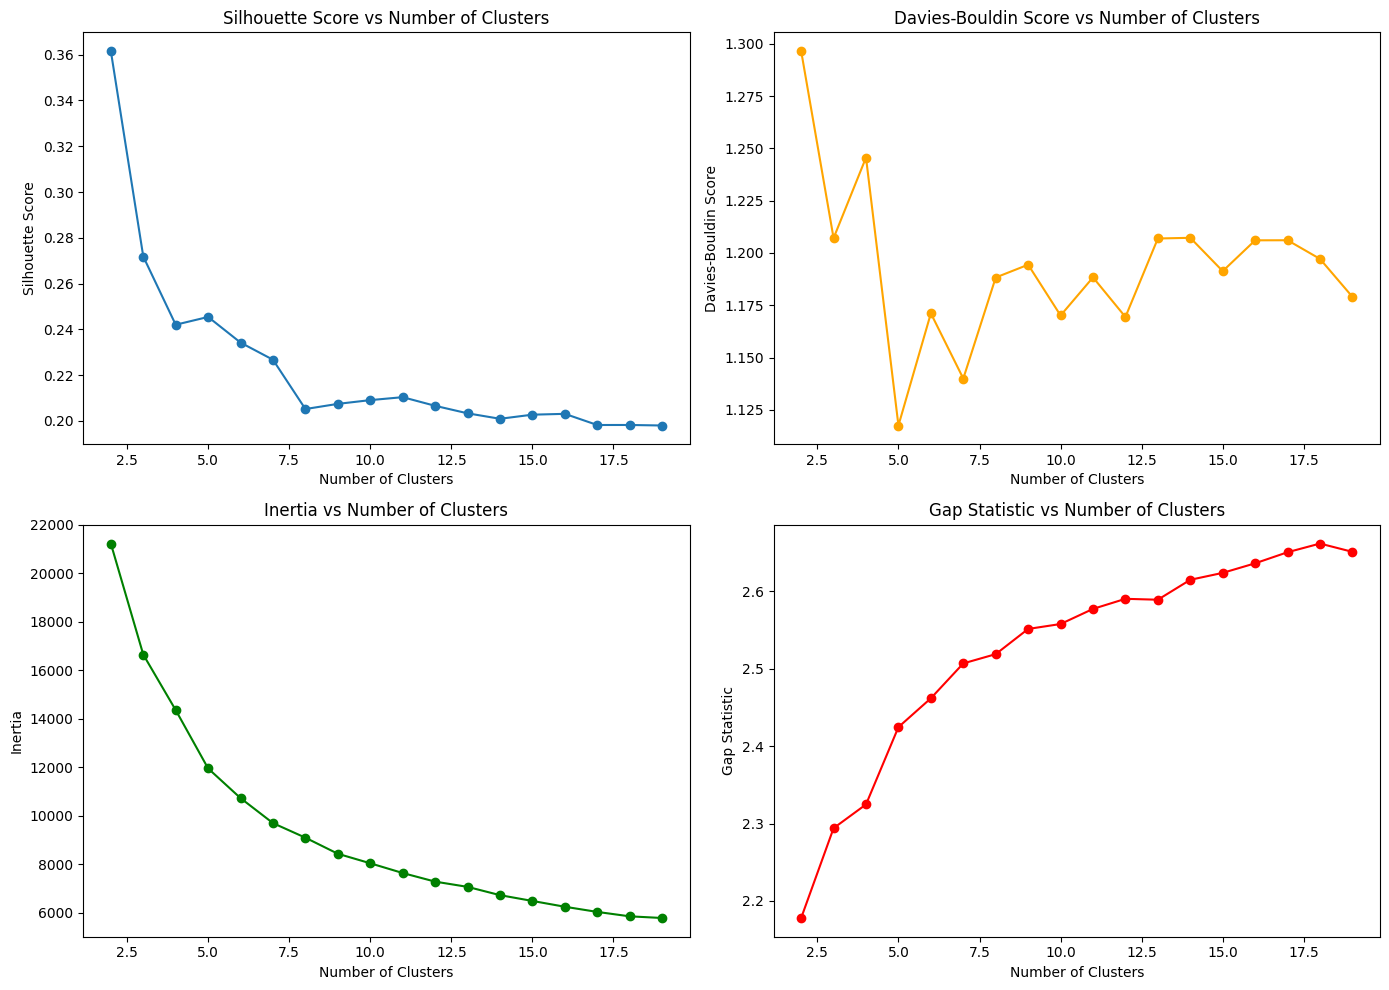

In [5]:
# Helper function to compute the Gap Statistic
def calculate_gap_statistic(data, k, actual_inertia, n_refs=5):
    # Get the bounding box of the data
    mins = np.min(data, axis=0)
    maxs = np.max(data, axis=0)
    shape = data.shape
    
    ref_inertias = []
    # Generate random reference datasets and find their inertias
    for _ in range(n_refs):
        ref_data = np.random.uniform(mins, maxs, shape)
        km = KMeans(n_clusters=k, random_state=42, n_init='auto')
        km.fit(ref_data)
        ref_inertias.append(km.inertia_)
        
    # Gap = expected log(inertia) of random data - log(inertia) of actual data
    gap = np.mean(np.log(ref_inertias)) - np.log(actual_inertia)
    return gap

sil_scores = []
db_scores = []
inertia_scores = []
gap_scores = []

k_max = 20
k_range = range(2, k_max)

for i in tqdm(k_range, desc="Evaluating KMeans for different cluster counts"):
    # Fit KMeans
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(scaled_matrix)
    
    # Calculate Standard Metrics
    sil = silhouette_score(scaled_matrix, labels)
    db = davies_bouldin_score(scaled_matrix, labels)
    actual_inertia = kmeans.inertia_
    
    # Calculate Gap Statistic using the actual inertia we just found
    gap = calculate_gap_statistic(scaled_matrix, i, actual_inertia, n_refs=5)
    
    # Append to lists
    sil_scores.append(sil)
    db_scores.append(db)
    inertia_scores.append(actual_inertia)
    gap_scores.append(gap)

# Plotting
plt.figure(figsize=(14, 10))

# 1. Silhouette Score (Higher is better)
plt.subplot(2, 2, 1)
plt.plot(k_range, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

# 2. Davies-Bouldin Score (Lower is better)
plt.subplot(2, 2, 2)
plt.plot(k_range, db_scores, marker='o', color='orange')
plt.title('Davies-Bouldin Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')

# 3. Inertia (Elbow Method - look for the "kink")
plt.subplot(2, 2, 3)
plt.plot(k_range, inertia_scores, marker='o', color='green')
plt.title('Inertia vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

# 4. Gap Statistic (Higher is better, or first local maximum)
plt.subplot(2, 2, 4)
plt.plot(k_range, gap_scores, marker='o', color='red')
plt.title('Gap Statistic vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Gap Statistic')

plt.tight_layout()
plt.show()

In [6]:
best_k = 5 # 9

labels = KMeans(n_clusters=best_k, random_state=42, n_init='auto').fit_predict(scaled_matrix)
df = df.with_columns(pl.Series("cluster_label", labels))

sil = silhouette_score(scaled_matrix, labels)
db = davies_bouldin_score(scaled_matrix, labels)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")

Silhouette Score: 0.2454
Davies-Bouldin Score: 1.1176


In [7]:
reducer = 't-SNE'
create_chemiscope_viewer(df, scaled_matrix, labels=labels, reduction_method=reducer)

Running t-SNE dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_t-SNE_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_t-SNE_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - t-SNE Clustering'}, settings={'map': {'x': {'property': 't-SNE_1'}, 'y'…

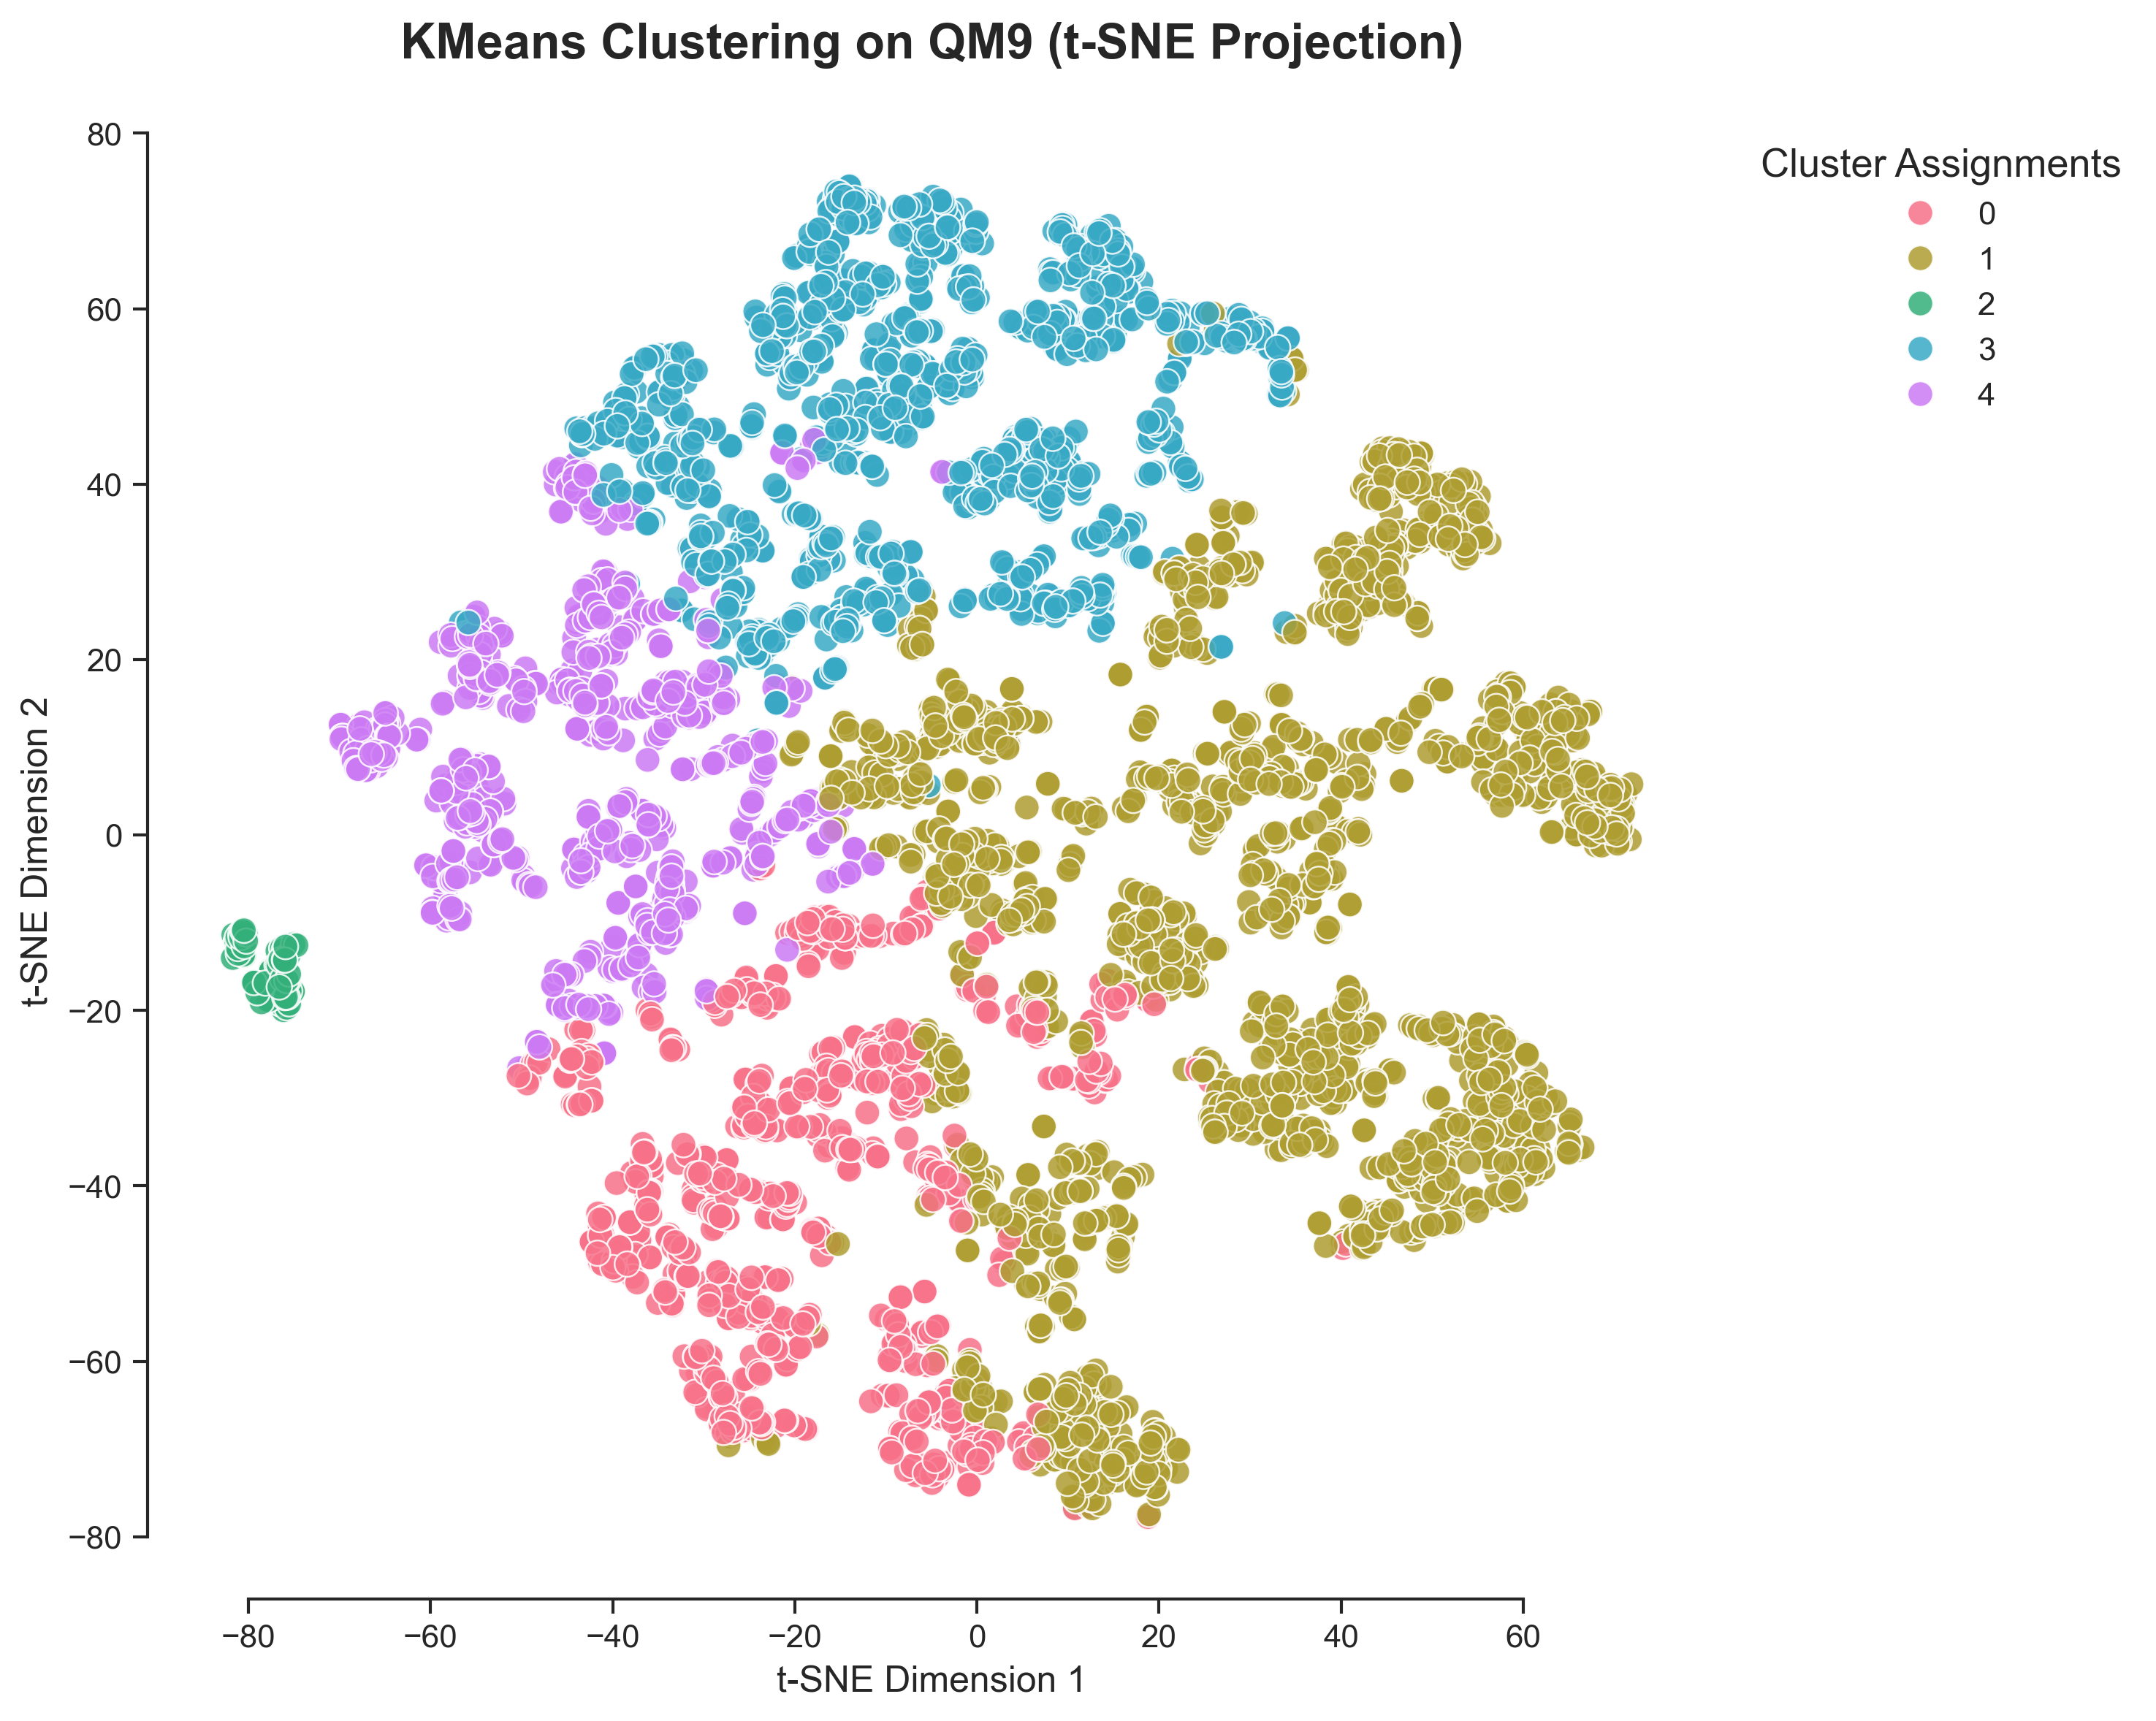

In [8]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
pca_embedding = tsne.fit_transform(scaled_matrix)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        pca_embedding[noise_mask, 0], 
        pca_embedding[noise_mask, 1], 
        c='#B0B0B0',     
        s=15,            
        alpha=0.4,         
        label='Noise (-1)',
        edgecolors='none'
    )

cluster_mask = (labels != -1)
if cluster_mask.any():
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=pca_embedding[cluster_mask, 0], 
        y=pca_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,              
        alpha=0.85,        
        edgecolor='white', 
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

ax.set_title('KMeans Clustering on QM9 (t-SNE Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='medium')

sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

plt.savefig("figures/qm9/clustering/kmeans/invariant_features/kmeans_tsne_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

In [9]:
def average_numeric_by_cluster(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups a Polars DataFrame by 'cluster_label' and returns 
    the mean of all numeric columns along with the count of elements.
    """
    return (
        df.group_by("cluster_label")
        .agg(
            pl.len().alias("count"),  # Adds the number of elements per cluster
            pl.col(pl.NUMERIC_DTYPES).mean()
        )
        .sort("cluster_label")
    )

print("KMeans")
cluster_averages = average_numeric_by_cluster(df)
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    print(cluster_averages)


KMeans
shape: (5, 55)
┌───────────────┬───────┬───────────┬────────────┬───────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┐
│ cluster_label ┆ count ┆ num_atoms ┆ mol_weight ┆ logp      ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_rings ┆ num_aromatic_rings ┆ coordination

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_72639/4181925054.py:10: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).mean()


# Interpretation
- Features : electron affinity and coord
- PCA 1: ?
- PCA 2: Most likely standard devation in electron affinity. 

## Why Fluorine is seperated.
- Electron Affinity measures the amount of energy released when an electron is added to a neutral molecule.
- If a molecule contains fluorine alongside carbon and hydrogen, its atomic electron affinities are going to be heavily skewed. The average will shoot up, and more importantly, the variance (standard deviation) will max out.

## Cluster 4 (flour)
- Because Fluorine has such an extreme electron affinity compared to Carbon or Hydrogen, any molecule containing it will have a massively inflated standard deviation. 
- PCA Dimension 2 is almost certainly capturing that standard deviation. K-Means had no choice but to group these extreme outliers into their own dedicated cluster because their distance from the "normal" molecules is so vast.


## Cluster 1: 
- The largest, most sp3 saturated (86.8%), and least polar (TPSA = 22.1). These are the stable, pure hydrocarbon and simple ether backbones sitting on the far right of the PCA plot.

## Cluster 3 
- Still structurally identical to Cluster 1, but separated purely by the presence of alcohols (0.31) and the resulting hydrogen bonding. They sit perfectly parallel to the Aliphatics.

## Cluster 2: 
- Still the domain of the highly unsaturated (60.0% sp2), highly aromatic (0.76), and highly polar (TPSA = 58.9) amines and heavy halides. These sit on the far left.

## Cluster 0: 
- Still the mathematical middle ground bridging the bulky non-polar molecules and the flat polar molecules, characterized by moderate sp3/sp2 mixing and average electron affinity.